## Support Vector Classifier

This notebook examines the SupportVectorClassifier (SVC) to predict customer satisfaction.

In [1]:
%%capture
%pip install hpsklearn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, GridSearchCV
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score, roc_curve
import utils
from utils import *
warnings.filterwarnings(action='ignore')

In [3]:
df = pd.read_csv('../../data/ACME-HappinessSurvey2020_shrunk.csv')

df.head()

,customer satisfaction,my order was delivered on time,contents of my order was as I expected,I ordered everything I wanted to order,I paid good price for my order,I am satisfied with my courier,the app makes ordering easy
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [4]:
y = df['customer satisfaction'].values
X = df.drop('customer satisfaction', axis=1)

In [5]:
seed = 5249

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, random_state=seed, shuffle=True
)

In [7]:
svc = SVC(random_state=seed, kernel='linear')

svc.fit(X_train, y_train)

return_scores(svc, X_train, X_test, y_train, y_test)

,Train Scores,Test Scores
Accuracy,0.690000,0.461538
Recall,0.709091,0.428571


In [12]:
params = {
    'C': 10**np.linspace(-3,4,25)
}

kfold = KFold(n_splits=10, shuffle=True, random_state=seed)

grid = RandomizedSearchCV(estimator=svc,
                    param_distributions=params,
                    scoring=['accuracy', 'recall'],
                    n_jobs=-1,
                    cv=kfold,
                    return_train_score=True,
                    refit=False,
                    random_state=seed)

grid.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=10, random_state=5249, shuffle=True),
                   estimator=SVC(kernel='linear', random_state=5249), n_jobs=-1,
                   param_distributions={'C': array([1.00000000e-03, 1.95734178e-03, 3.83118685e-03, 7.49894209e-03,
       1.46779927e-02, 2.87298483e-02, 5.62341325e-02, 1.10069417e-01,
       2.15443469e-01, 4.21696503e-01, 8.25404185e-01, 1.61559810e+00,
       3.16227766e+00, 6.18965819e+00, 1.21152766e+01, 2.37137371e+01,
       4.64158883e+01, 9.08517576e+01, 1.77827941e+02, 3.48070059e+02,
       6.81292069e+02, 1.33352143e+03, 2.61015722e+03, 5.10896977e+03,
       1.00000000e+04])},
                   random_state=5249, refit=False, return_train_score=True,
                   scoring=['accuracy', 'recall'])

In [13]:
grid_df = pd.DataFrame(grid.cv_results_)
grid_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,split2_train_recall,split3_train_recall,split4_train_recall,split5_train_recall,split6_train_recall,split7_train_recall,split8_train_recall,split9_train_recall,mean_train_recall,std_train_recall
0,0.106889,0.057523,0.034824,0.022970,0.001957,{'C': 0.0019573417814876598},0.6,0.7,0.9,0.2,...,1.00000,1.000000,1.00,1.00,1.00,1.000000,1.000000,1.000000,1.000000,0.000000
1,0.016027,0.020084,0.008915,0.003613,0.421697,{'C': 0.4216965034285822},0.7,0.5,0.5,0.7,...,0.73913,0.754717,0.74,0.84,0.72,0.764706,0.734694,0.714286,0.745141,0.037256
2,0.011637,0.002966,0.023136,0.022280,46.415888,{'C': 46.41588833612782},0.6,0.5,0.6,0.7,...,0.73913,0.773585,0.72,0.84,0.72,0.764706,0.755102,0.755102,0.751150,0.037389
3,0.034422,0.022409,0.009472,0.005470,177.827941,{'C': 177.82794100389228},0.6,0.5,0.6,0.7,...,0.73913,0.754717,0.74,0.72,0.72,0.784314,0.755102,0.755102,0.741224,0.023769
4,0.077104,0.038142,0.014741,0.010173,348.070059,{'C': 348.0700588428413},0.6,0.5,0.6,0.7,...,0.73913,0.754717,0.74,0.70,0.72,0.784314,0.755102,0.755102,0.739224,0.026189


In [14]:
grid_df.sort_values(by='param_C', ascending=True, inplace=True)

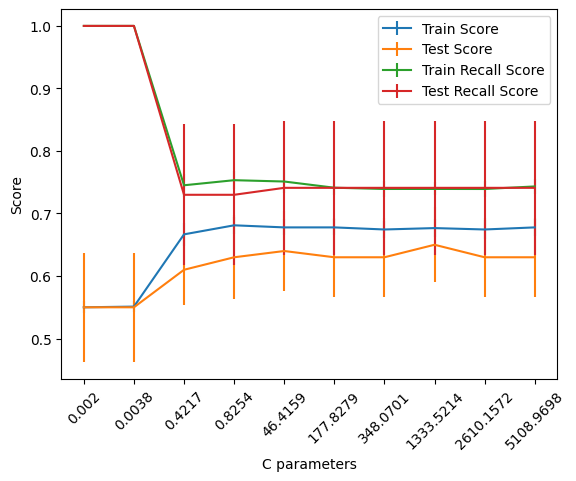

In [15]:
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_train_accuracy'],
    yerr=grid_df['std_train_accuracy']/np.sqrt(4),
    label='Train Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_test_accuracy'],
    yerr=grid_df['std_test_accuracy']/np.sqrt(4),
    label='Test Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_train_recall'],
    yerr=grid_df['std_train_recall']/np.sqrt(4),
    label='Train Recall Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_test_recall'],
    yerr=grid_df['std_test_recall']/np.sqrt(4),
    label='Test Recall Score'
    )
plt.xticks(np.arange(len(grid_df['param_C'])), round(grid_df['param_C'], 4), rotation=45)
plt.xlabel('C parameters')
plt.ylabel('Score')
plt.legend()
plt.show()

In [16]:
.4217-((.4217-.0038)/2)

0.21275000000000002

In [17]:
svc_tuned = SVC(C=.2128,
                kernel='linear',
                random_state=seed
                ).fit(X_train, y_train)

preds = svc_tuned.predict(X_test)

return_scores(svc_tuned, X_train, X_test, y_train, y_test)

,Train Scores,Test Scores
Accuracy,0.640000,0.423077
Recall,0.727273,0.428571


In [18]:
coef_df = pd.DataFrame({
    'Coefficients': svc_tuned.coef_[0]
}, index=X_train.columns).sort_values(by='Coefficients', ascending=True)

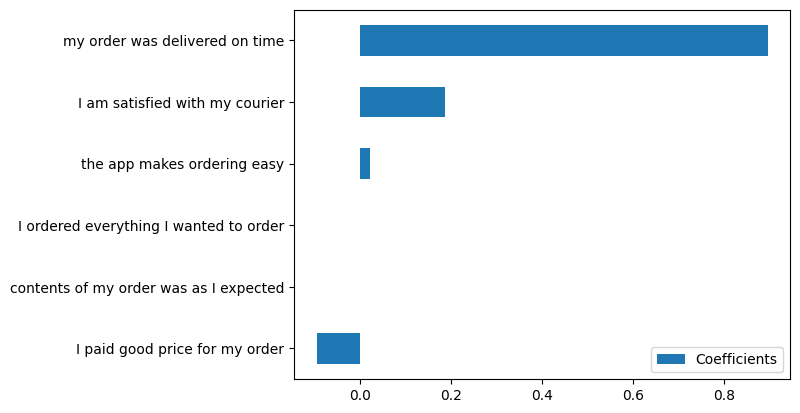

In [19]:
coef_df.plot(kind='barh')
plt.show()

In [20]:
import pathlib

path = pathlib.Path('../../feature importances/svc_coefs.csv')

if path.exists() != True:
    coef_df.to_csv(path)

### Non-Linear

In [21]:
svc_poly = SVC(random_state=seed,
               kernel='poly')

params = {
    'C': 10**np.linspace(-3,4,25),
}

grid = GridSearchCV(estimator=svc_poly,
                    param_grid=params,
                    scoring=['accuracy', 'recall'],
                    n_jobs=-1,
                    cv=kfold,
                    refit=False,
                    return_train_score=True)

grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=5249, shuffle=True),
             estimator=SVC(kernel='poly', random_state=5249), n_jobs=-1,
             param_grid={'C': array([1.00000000e-03, 1.95734178e-03, 3.83118685e-03, 7.49894209e-03,
       1.46779927e-02, 2.87298483e-02, 5.62341325e-02, 1.10069417e-01,
       2.15443469e-01, 4.21696503e-01, 8.25404185e-01, 1.61559810e+00,
       3.16227766e+00, 6.18965819e+00, 1.21152766e+01, 2.37137371e+01,
       4.64158883e+01, 9.08517576e+01, 1.77827941e+02, 3.48070059e+02,
       6.81292069e+02, 1.33352143e+03, 2.61015722e+03, 5.10896977e+03,
       1.00000000e+04])},
             refit=False, return_train_score=True,
             scoring=['accuracy', 'recall'])

In [22]:
grid_df = pd.DataFrame(grid.cv_results_)
grid_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,split2_train_recall,split3_train_recall,split4_train_recall,split5_train_recall,split6_train_recall,split7_train_recall,split8_train_recall,split9_train_recall,mean_train_recall,std_train_recall
0,0.073525,0.052350,0.021050,0.009787,0.001000,{'C': 0.001},0.8,0.4,0.4,0.6,...,0.673913,0.735849,0.68,0.68,0.7,0.686275,0.714286,0.673469,0.686394,0.025890
1,0.013892,0.020729,0.009707,0.004876,0.001957,{'C': 0.0019573417814876598},0.7,0.5,0.5,0.7,...,0.739130,0.754717,0.68,0.70,0.7,0.705882,0.734694,0.673469,0.704886,0.027365
2,0.005328,0.001432,0.006787,0.002930,0.003831,{'C': 0.003831186849557289},0.8,0.6,0.5,0.8,...,0.739130,0.698113,0.68,0.70,0.7,0.705882,0.714286,0.673469,0.697228,0.022524
3,0.005331,0.002246,0.008388,0.003191,0.007499,{'C': 0.007498942093324558},0.8,0.6,0.5,0.8,...,0.739130,0.679245,0.68,0.70,0.7,0.705882,0.734694,0.653061,0.695341,0.028034
4,0.004467,0.001218,0.006031,0.001240,0.014678,{'C': 0.014677992676220698},0.8,0.6,0.5,0.8,...,0.739130,0.716981,0.68,0.70,0.7,0.705882,0.734694,0.673469,0.701155,0.025340


In [23]:
grid_df.sort_values(by='param_C', ascending=True, inplace=True)

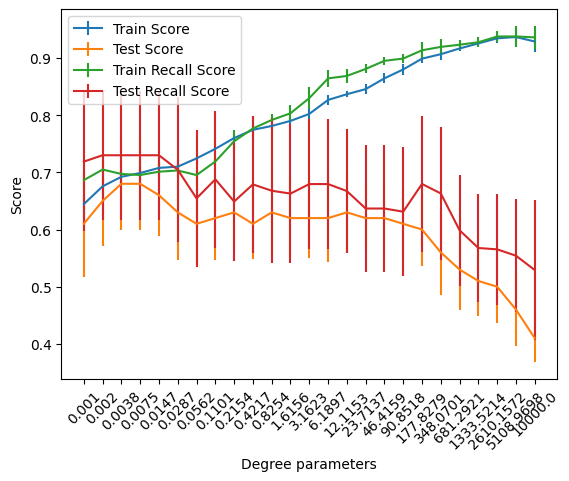

In [24]:
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_train_accuracy'],
    yerr=grid_df['std_train_accuracy']/np.sqrt(4),
    label='Train Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_test_accuracy'],
    yerr=grid_df['std_test_accuracy']/np.sqrt(4),
    label='Test Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_train_recall'],
    yerr=grid_df['std_train_recall']/np.sqrt(4),
    label='Train Recall Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_test_recall'],
    yerr=grid_df['std_test_recall']/np.sqrt(4),
    label='Test Recall Score'
    )
plt.xticks(np.arange(len(grid_df['param_C'])), round(grid_df['param_C'], 4), rotation=45)
plt.xlabel('Degree parameters')
plt.ylabel('Score')
plt.legend()
plt.show()

In [25]:
svc_poly.C = 12.1153
svc_poly.fit(X_train, y_train)

return_scores(svc_poly, X_train, X_test, y_train, y_test)

,Train Scores,Test Scores
Accuracy,0.840000,0.538462
Recall,0.890909,0.428571


In [26]:
from sklearn.model_selection import GridSearchCV

params = {
    'gamma': 10**np.linspace(-2,4,15)
}

grid = RandomizedSearchCV(estimator=svc_poly,
                    param_distributions=params,
                    scoring=['accuracy', 'recall'],
                    n_jobs=-1,
                    cv=kfold,
                    refit=False,
                    return_train_score=True,
                    random_state=seed)

grid.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
grid_df = pd.DataFrame(grid.cv_results_)
grid_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_kernel,param_gamma,param_degree,params,split0_test_accuracy,split1_test_accuracy,...,mean_test_recall,std_test_recall,rank_test_recall,split0_train_recall,split1_train_recall,split2_train_recall,split3_train_recall,split4_train_recall,mean_train_recall,std_train_recall
0,0.029026,0.013426,0.030432,0.007700,poly,0.001,3,"{'kernel': 'poly', 'gamma': 0.001, 'degree': 3}",0.461538,0.307692,...,0.675000,0.415331,2,0.60,0.000000,1.000000,1.000000,1.000000,0.720000,0.391918
1,0.017650,0.011882,0.025191,0.017236,poly,0.010,3,"{'kernel': 'poly', 'gamma': 0.01, 'degree': 3}",0.461538,0.769231,...,0.721984,0.216311,1,0.68,0.500000,0.862069,0.538462,0.750000,0.666106,0.133804
2,0.011832,0.004052,0.006600,0.001702,poly,0.100,3,"{'kernel': 'poly', 'gamma': 0.1, 'degree': 3}",0.538462,0.692308,...,0.659762,0.246307,3,0.80,0.791667,0.758621,0.769231,0.785714,0.781046,0.015075
3,0.330167,0.210978,0.007174,0.004855,poly,1.000,3,"{'kernel': 'poly', 'gamma': 1.0, 'degree': 3}",0.538462,0.615385,...,0.556190,0.116541,4,0.96,0.958333,1.000000,1.000000,1.000000,0.983667,0.020011
4,0.313026,0.204559,0.006502,0.005557,poly,10.000,3,"{'kernel': 'poly', 'gamma': 10.0, 'degree': 3}",0.538462,0.615385,...,0.556190,0.116541,4,0.96,0.958333,1.000000,1.000000,1.000000,0.983667,0.020011
5,0.339126,0.160205,0.012274,0.007567,poly,100.000,3,"{'kernel': 'poly', 'gamma': 100.0, 'degree': 3}",0.538462,0.615385,...,0.556190,0.116541,4,0.96,0.958333,1.000000,1.000000,1.000000,0.983667,0.020011


In [ ]:
grid_df.sort_values(by='param_gamma', ascending=True, inplace=True)

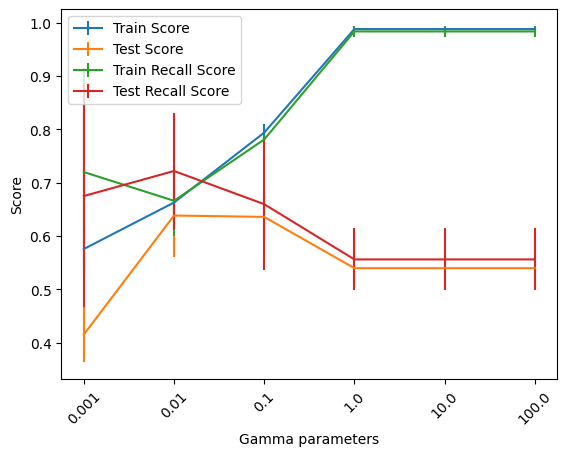

In [ ]:
plt.errorbar(
    np.arange(len(grid_df['param_gamma'])),
    grid_df['mean_train_accuracy'],
    yerr=grid_df['std_train_accuracy']/np.sqrt(4),
    label='Train Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_gamma'])),
    grid_df['mean_test_accuracy'],
    yerr=grid_df['std_test_accuracy']/np.sqrt(4),
    label='Test Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_gamma'])),
    grid_df['mean_train_recall'],
    yerr=grid_df['std_train_recall']/np.sqrt(4),
    label='Train Recall Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_gamma'])),
    grid_df['mean_test_recall'],
    yerr=grid_df['std_test_recall']/np.sqrt(4),
    label='Test Recall Score'
    )
plt.xticks(np.arange(len(grid_df['param_gamma'])), round(grid_df['param_gamma'], 4), rotation=45)
plt.xlabel('Gamma parameters')
plt.ylabel('Score')
plt.legend()
plt.show()

In [27]:
svc_poly.gamma = .1
svc_poly.fit(X_train, y_train)

return_scores(svc_poly, X_train, X_test, y_train, y_test)

,Train Scores,Test Scores
Accuracy,0.830000,0.538462
Recall,0.872727,0.428571


In [28]:
from sklearn.metrics import precision_score, f1_score

for c in 10**np.linspace(-3, 4, 20):    
    svc_tuned = SVC(
        C=c,
        kernel='poly',
        gamma=.1,
        degree=6,
        random_state=seed
    ).fit(X_train, y_train)

    print(f"C: {c}")
    print(return_scores(svc_tuned, X_train, X_test, y_train, y_test))

C: 0.001
          Train Scores  Test Scores
Accuracy      0.790000     0.576923
Recall        0.781818     0.428571
C: 0.002335721469090121
          Train Scores  Test Scores
Accuracy      0.810000     0.461538
Recall        0.818182     0.357143


C: 0.00545559478116852
          Train Scores  Test Scores
Accuracy      0.820000     0.423077
Recall        0.781818     0.285714
C: 0.012742749857031334
          Train Scores  Test Scores
Accuracy      0.830000     0.461538
Recall        0.818182     0.285714
C: 0.029763514416313176
          Train Scores  Test Scores
Accuracy      0.860000     0.500000
Recall        0.818182     0.357143
C: 0.06951927961775606
          Train Scores  Test Scores
Accuracy      0.880000     0.538462
Recall        0.836364     0.428571
C: 0.1623776739188721
          Train Scores  Test Scores
Accuracy      0.910000     0.615385
Recall        0.872727     0.571429
C: 0.37926901907322497
          Train Scores  Test Scores
Accuracy      0.930000     0.615385
Recall        0.909091     0.571429
C: 0.8858667904100823
          Train Scores  Test Scores
Accuracy      0.950000     0.653846
Recall        0.927273     0.571429
C: 2.069138081114788
          Train Scores  Test Scores
Accuracy      0.960000    

In [29]:
svc_tuned = SVC(
        C=0.8858667904100823,
        kernel='poly',
        gamma=.1,
        degree=6,
        random_state=seed
    ).fit(X_train, y_train)

return_scores(svc_tuned, X_train, X_test, y_train, y_test)

,Train Scores,Test Scores
Accuracy,0.950000,0.653846
Recall,0.927273,0.571429


In [25]:
# pred1, pred2, pred3, pred4, pred5, pred6 = [], [], [], [], [], []

# for alpha in [.001, .01, .1, 1.0, 10.0, 100.0, 1000.0, 10000.0]:
#     ridge_class = RidgeClassifierCV(alphas=[alpha], cv=4)

#     ridge_class.fit(X_train, y_train)

#     ridge_preds = ridge_class.predict(X_test)

#     coefs = ridge_class.coef_
#     pred1.append(coefs[0])
#     pred2.append(coefs[1])
#     pred3.append(coefs[2])
#     pred4.append(coefs[3])
#     pred5.append(coefs[4])
#     pred6.append(coefs[5])

#     score = ridge_class.score(X_test, y_test)

#     print(f"Ridge Classifier Score: {score}")
#     # print(f"Coefs: {ridge_class.coef_}")
#     print(f"Ridge Classifier Error rate: {1-score}\n")

In [26]:
# pred_coefs = [pred1, pred2, pred3, pred4, pred5, pred6]

In [27]:
# plt.figure(figsize=(12,6))

# for i, col in zip(pred_coefs, df.columns[1:]):
#     plt.plot(np.arange(len(pred1)), i, label=col)
#     plt.legend()
# plt.hlines(y=[0], xmin=[0], xmax=[7], colors='black', linestyle='dashed')
# plt.show()

In [28]:
# ridge_2 = RidgeClassifierCV(alphas=[1000])
# ridge_2.fit(X_train, y_train)

# ridge_2.score(X_train, y_train), ridge_2.score(X_test, y_test)